# TRÍCH XUẤT BẢNG TỪ ẢNH TÀI LIỆU

Notebook baseline độc lập; toàn bộ mã nguồn nằm trong các cell bên dưới.


## 1. Cấu hình đường dẫn


In [1]:
!pip install -q --upgrade pip setuptools wheel
!pip install -q einops gdown lmdb pillow scikit-image albumentations
!pip install -q vietocr==0.3.13 --no-deps

In [2]:
import os

# Phải đặt trước khi torch khởi tạo CUDA.
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import time
import zipfile
import subprocess

import torch

# Cố định kết quả giữa các lần chạy: cùng seed -> cùng file nộp.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)


# ============================================================
# Tải data.zip
# ============================================================

ROOT = Path('/content')
ZIP_PATH = ROOT / 'data.zip'

FILE_ID = '12nyL3EgIc37Ng37bRuY-QTl0n-d8ti6I'

if not ZIP_PATH.is_file():
    print('[data] Đang tải data.zip từ Google Drive...')

    subprocess.run(
        [
            'gdown',
            '--id',
            FILE_ID,
            '--output',
            str(ZIP_PATH),
        ],
        check=True
    )

    print(f'[data] Đã tải: {ZIP_PATH}')
else:
    print(f'[data] Đã có {ZIP_PATH}, bỏ qua bước tải.')


# ============================================================
# Giải nén data.zip
# ============================================================

EXTRACT_DIR = ROOT / 'data'

if not EXTRACT_DIR.exists():
    print(f'[data] Đang giải nén {ZIP_PATH} -> {EXTRACT_DIR}...')

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print('[data] Giải nén data.zip hoàn tất.')
else:
    print(f'[data] Đã có {EXTRACT_DIR}, bỏ qua bước giải nén data.zip.')


# ============================================================
# Path dữ liệu
# ============================================================

# data.zip có sẵn folder "data" bên trong
DATA = EXTRACT_DIR / 'data'


# ============================================================
# Giải nén private_test.zip
# ============================================================

PRIVATE_ZIP = DATA / 'private_test.zip'
PRIVATE_DIR = DATA / 'private_test'

PRIVATE_PASSWORD = b'225554'

if PRIVATE_ZIP.is_file():

    if not PRIVATE_DIR.exists():
        print(f'[data] Đang giải nén {PRIVATE_ZIP} -> {DATA}...')

        try:
            with zipfile.ZipFile(PRIVATE_ZIP, 'r') as zip_ref:
                zip_ref.extractall(
                    DATA,
                    pwd=PRIVATE_PASSWORD
                )

            print('[data] Giải nén private_test.zip hoàn tất.')

        except RuntimeError as e:
            raise RuntimeError(
                'Không thể giải nén private_test.zip. '
                'Kiểm tra lại mật khẩu hoặc file ZIP.'
            ) from e

    else:
        print(f'[data] Đã có {PRIVATE_DIR}, bỏ qua bước giải nén private_test.zip.')

else:
    print(f'[data] Không tìm thấy {PRIVATE_ZIP}.')


# ============================================================
# Kiểm tra training_set
# ============================================================

TRAIN_DIR = DATA / 'training_set'

if not (TRAIN_DIR / 'manifest.jsonl').is_file():
    raise FileNotFoundError(
        f'Không tìm thấy {TRAIN_DIR / "manifest.jsonl"}'
    )


# ============================================================
# Runs
# ============================================================

RUNS = ROOT / 'runs'
RUNS.mkdir(parents=True, exist_ok=True)


# ============================================================
# Chọn split
# ============================================================

SPLIT = 'private_test'


# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)


# ============================================================
# In cấu hình
# ============================================================

print(f'[cấu hình] ROOT={ROOT} | SPLIT={SPLIT}')
print(f'[cấu hình] DATA={DATA}')
print(f'[cấu hình] TRAIN_DIR={TRAIN_DIR}')
print(f'[cấu hình] PRIVATE_DIR={PRIVATE_DIR}')

print('[cấu hình] thiết bị: ' + (
    f'{DEVICE} ({torch.cuda.get_device_name(0)})'
    if DEVICE.type == 'cuda'
    else str(DEVICE)
))

[data] Đã có /content/data.zip, bỏ qua bước tải.
[data] Đã có /content/data, bỏ qua bước giải nén data.zip.
[data] Đã có /content/data/data/private_test, bỏ qua bước giải nén private_test.zip.
[cấu hình] ROOT=/content | SPLIT=private_test
[cấu hình] DATA=/content/data/data
[cấu hình] TRAIN_DIR=/content/data/data/training_set
[cấu hình] PRIVATE_DIR=/content/data/data/private_test
[cấu hình] thiết bị: cuda (Tesla T4)


In [3]:
# import os

# # Phải đặt trước khi torch khởi tạo CUDA.
# os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# from pathlib import Path
# import time

# import torch

# # Cố định kết quả giữa các lần chạy: cùng seed -> cùng file nộp.
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
# torch.use_deterministic_algorithms(True, warn_only=True)

# ROOT = next((candidate for candidate in (Path.cwd(), Path.cwd() / 'TACVU2', Path('/home/user/TACVU2'))
#              if (candidate / 'data' / 'training_set' / 'manifest.jsonl').is_file()), None)
# if ROOT is None:
#     raise FileNotFoundError('Không tìm thấy TACVU2/data/training_set/manifest.jsonl; mở notebook từ thư mục project.')
# DATA = ROOT / 'data'
# TRAIN_DIR = DATA / 'training_set'
# RUNS = ROOT / 'runs'
# RUNS.mkdir(parents=True, exist_ok=True)
# SPLIT = 'training_set'  # Đổi thành 'private_test' trong phase private.

# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# print(f'[cấu hình] ROOT={ROOT} | SPLIT={SPLIT}')
# print('[cấu hình] thiết bị: ' + (f'{DEVICE} ({torch.cuda.get_device_name(0)})'
#       if DEVICE.type == 'cuda' else str(DEVICE)))


## 2. Xem nhanh dữ liệu


ID: train-00460
Image: images/train-00460_p01.jpg
Label: labels/train-00460.md


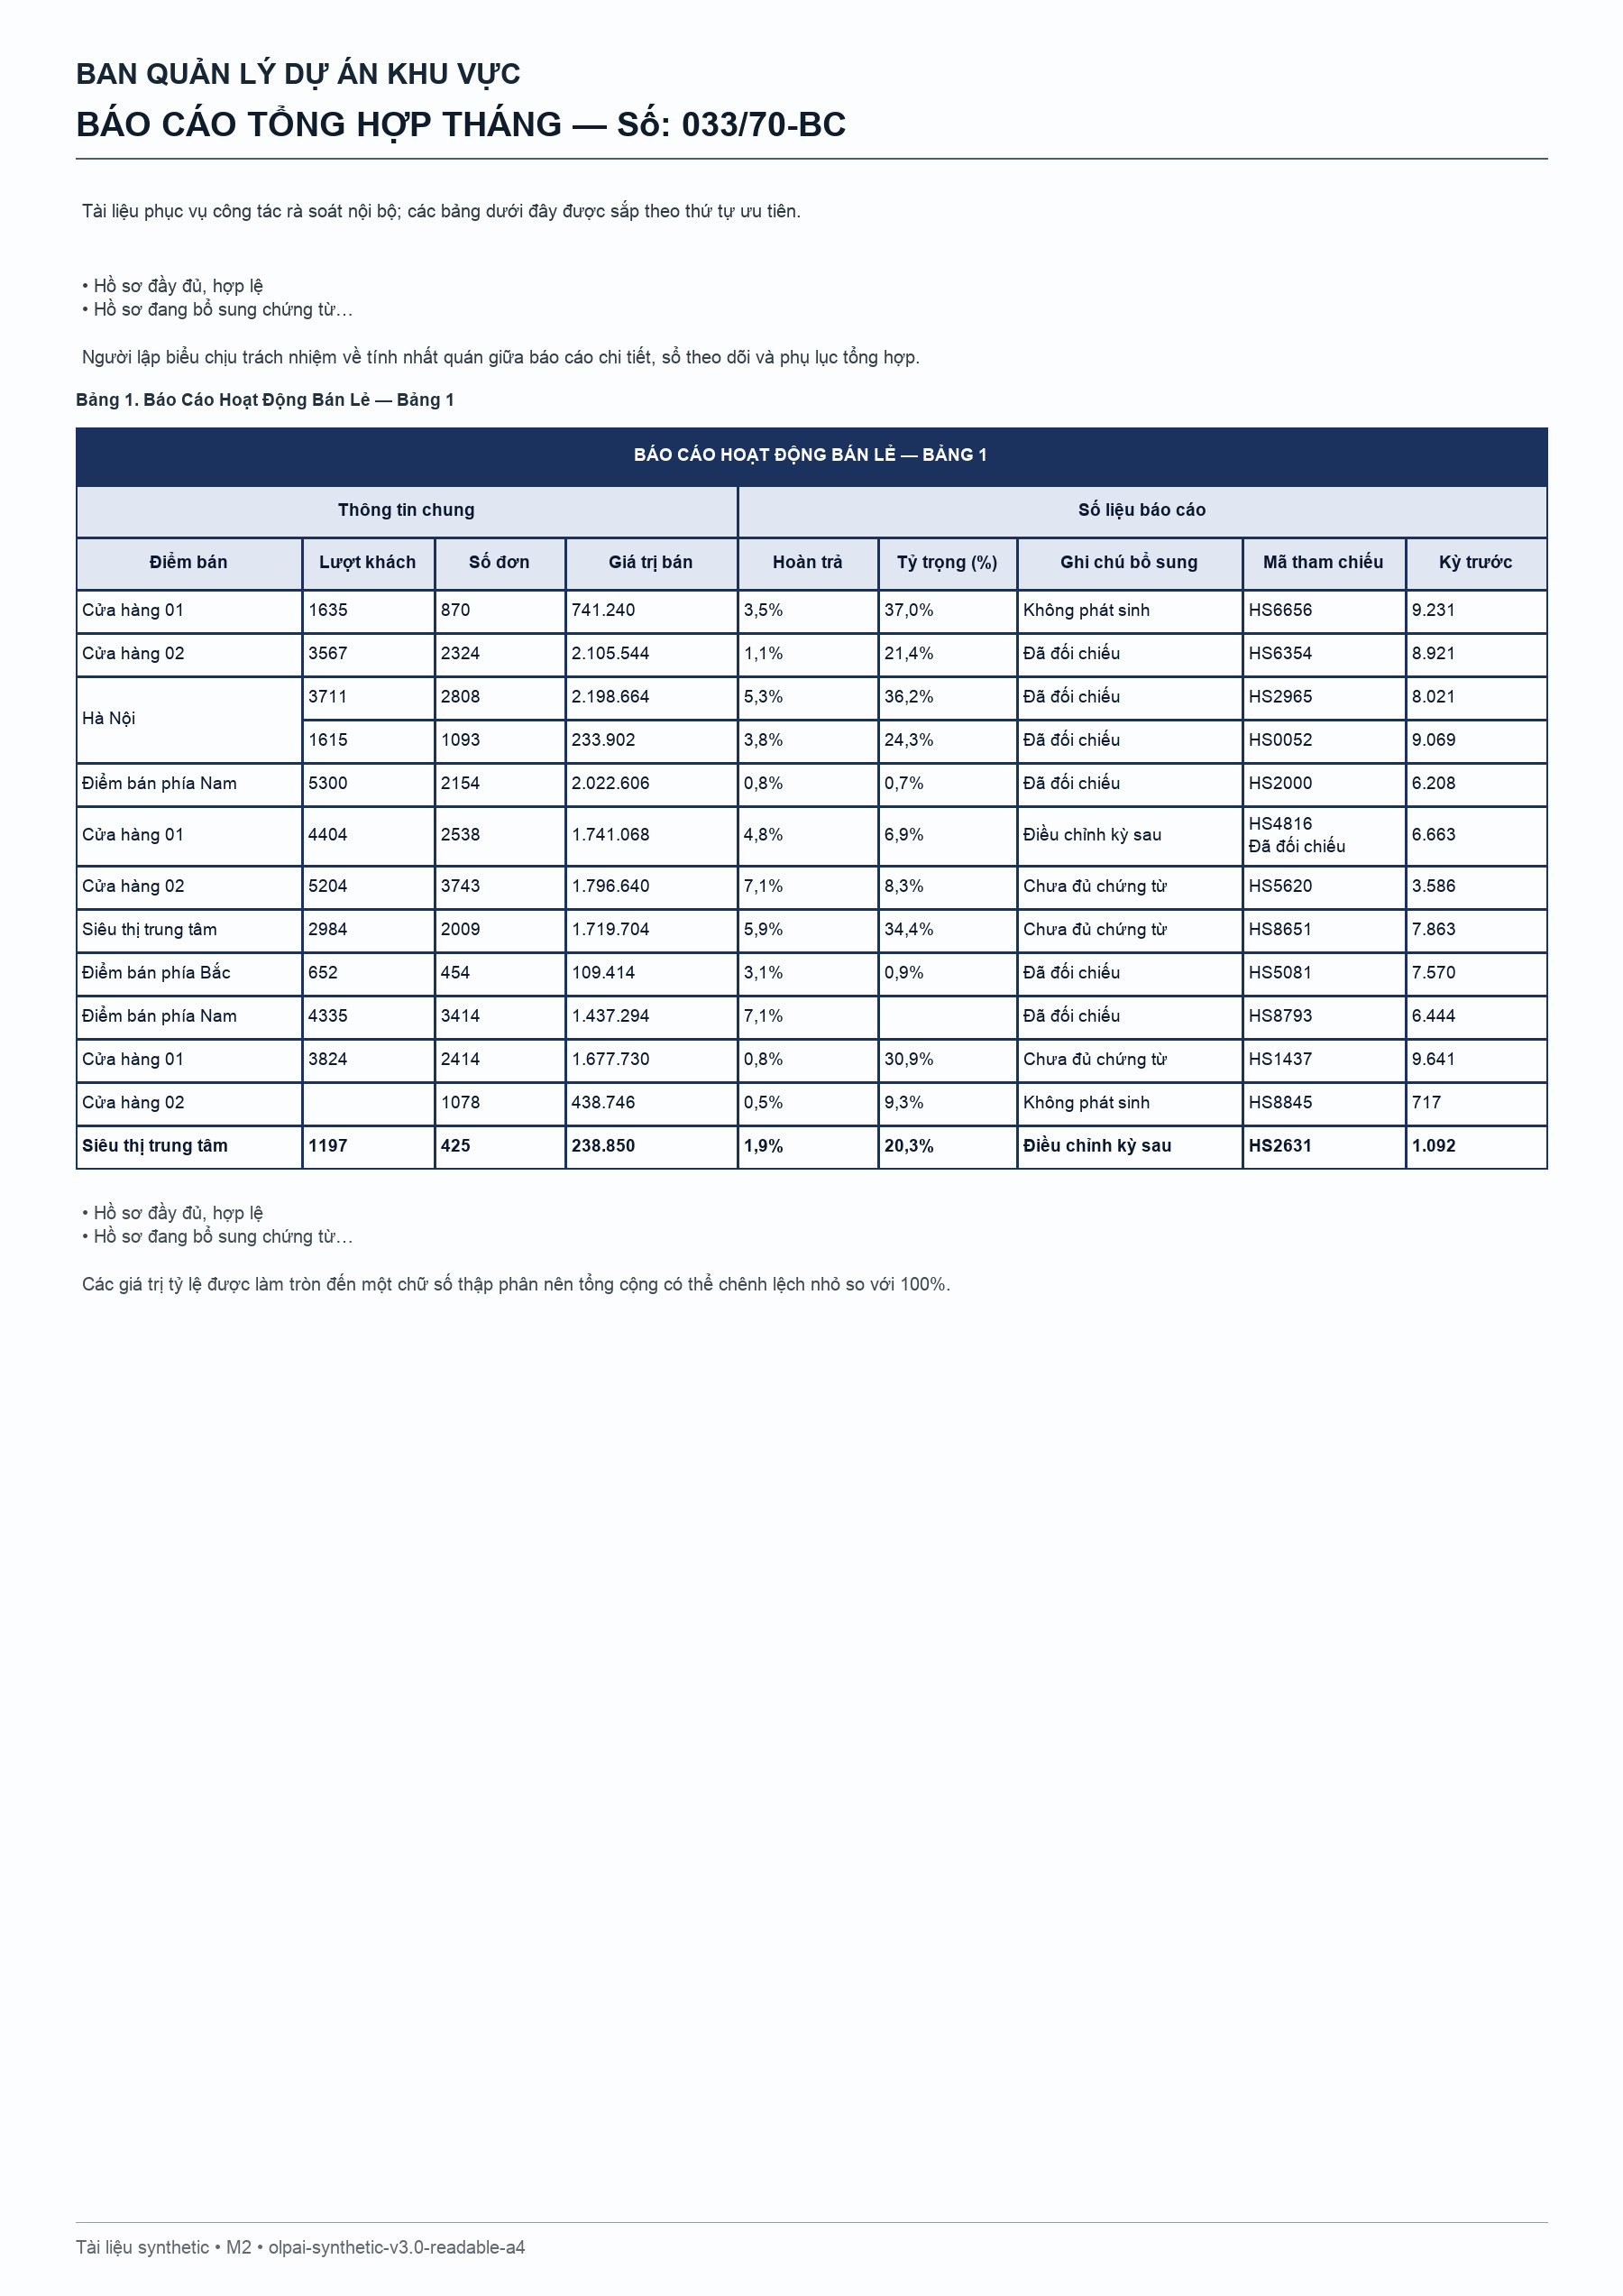

| **BÁO CÁO HOẠT ĐỘNG BÁN LẺ — BẢNG 1** | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Thông tin chung** | [[H]] | [[H]] | [[H]] | **Số liệu báo cáo** | [[H]] | [[H]] | [[H]] | [[H]] |
| **Điểm bán** | **Lượt khách** | **Số đơn** | **Giá trị bán** | **Hoàn trả** | **Tỷ trọng (%)** | **Ghi chú bổ sung** | **Mã tham chiếu** | **Kỳ trước** |
| Cửa hàng 01 | 1635 | 870 | 741.240 | 3,5% | 37,0% | Không phát sinh | HS6656 | 9.231 |
| Cửa hàng 02 | 3567 | 2324 | 2.105.544 | 1,1% | 21,4% | Đã đối chiếu | HS6354 | 8.921 |
| Hà Nội | 3711 | 2808 | 2.198.664 | 5,3% | 36,2% | Đã đối chiếu | HS2965 | 8.021 |
| [[V]] | 1615 | 1093 | 233.902 | 3,8% | 24,3% | Đã đối chiếu | HS0052 | 9.069 |
| Điểm bán phía Nam | 5300 | 2154 | 2.022.606 | 0,8% | 0,7% | Đã đối chiếu | HS2000 | 6.208 |
| Cửa hàng 01 | 4404 | 2538 | 1.741.068 | 4,8% | 6,9% | Điều chỉnh kỳ sau | HS4816<br>Đã đối chiếu | 6.663 |
| Cửa hàng 02 | 5204 | 3743 | 1.79

In [4]:
import json
from pathlib import Path
from PIL import Image
from IPython.display import display

rows = [
    json.loads(line)
    for line in (TRAIN_DIR / "manifest.jsonl").read_text(encoding="utf-8").splitlines()
    if line.strip()
]

target = "train-00460_p01"

for row in rows:
    for image_path in row["image_paths"]:
        if Path(image_path).stem == target:
            print("ID:", row["id"])
            print("Image:", image_path)
            print("Label:", row["label_path"])

            display(Image.open(TRAIN_DIR / image_path))
            print((TRAIN_DIR / row["label_path"]).read_text(encoding="utf-8"))

            break


## 3. Tiện ích dữ liệu và đóng gói kết quả


In [5]:
"""Minimal file/Markdown helpers for the Exam A student starter."""

import json
from pathlib import Path
import random
import unicodedata
import zipfile

import numpy as np


SEED = 2026080701


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)


def load_jsonl(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def load_manifest(split_dir: Path) -> list[dict]:
    path = split_dir / "manifest.jsonl"
    if not path.is_file():
        raise FileNotFoundError(f"Không thấy manifest: {path}")
    return load_jsonl(path)


def read_label(split_dir: Path, record: dict) -> str:
    path = split_dir / record["label_path"]
    return unicodedata.normalize("NFC", path.read_text(encoding="utf-8")).strip() + "\n"


def split_markdown_row(line: str) -> list[str]:
    if not (line.startswith("|") and line.endswith("|")):
        raise ValueError("Dòng Markdown không bắt đầu/kết thúc bằng dấu |")
    cells: list[str] = []
    current: list[str] = []
    escaped = False
    for character in line[1:-1]:
        if escaped:
            current.append("\\" + character)
            escaped = False
        elif character == "\\":
            escaped = True
        elif character == "|":
            cells.append("".join(current).strip())
            current = []
        else:
            current.append(character)
    if escaped:
        current.append("\\")
    cells.append("".join(current).strip())
    return cells


def parse_markdown(markdown: str) -> list[list[list[str]]]:
    tables: list[list[list[str]]] = []
    for block in unicodedata.normalize("NFC", markdown).strip().split("\n\n"):
        lines = [line.strip() for line in block.splitlines() if line.strip()]
        if len(lines) < 3:
            raise ValueError("Bảng có ít hơn ba dòng")
        rows = [split_markdown_row(line) for line in lines]
        width = len(rows[0])
        if width < 2 or any(len(row) != width for row in rows):
            raise ValueError("Số ô giữa các dòng không nhất quán")
        if any(cell != "---" for cell in rows[1]):
            raise ValueError("Thiếu dòng phân cách Markdown")
        tables.append([rows[0], *rows[2:]])
    if not tables:
        raise ValueError("Không có bảng")
    return tables


def is_valid_markdown(markdown: str) -> bool:
    try:
        parse_markdown(markdown)
        return "```" not in markdown
    except (ValueError, IndexError):
        return False


def write_predictions(output_dir: Path, records: list[dict], markdowns: list[str]) -> None:
    if len(records) != len(markdowns):
        raise ValueError("Số prediction không khớp manifest")
    output_dir.mkdir(parents=True, exist_ok=True)
    expected = {f"{record['id']}.md" for record in records}
    for existing in output_dir.glob("*.md"):
        if existing.name not in expected:
            existing.unlink()
    for record, markdown in zip(records, markdowns, strict=True):
        normalized = unicodedata.normalize("NFC", markdown).strip() + "\n"
        if not is_valid_markdown(normalized):
            raise ValueError(f"Prediction không hợp lệ: {record['id']}")
        (output_dir / f"{record['id']}.md").write_text(normalized, encoding="utf-8")


def make_predictions_zip(output_dir: Path, zip_path: Path) -> None:
    files = sorted(output_dir.glob("*.md"))
    if not files:
        raise ValueError("Thư mục prediction rỗng")
    zip_path.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
        for path in files:
            archive.write(path, path.name)   # tệp .md phải nằm ngay gốc ZIP


## 4. Xử lý cấu trúc bảng


In [8]:
"""OpenCV-only table structure helpers for Exam A.

The module contains no OCR model and reads no labels at inference time.  It is
deliberately conservative: reliable bordered tables are reconstructed; harder
borderless pages fall back to a small valid table in the public starter.
"""

from dataclasses import dataclass
from pathlib import Path

import cv2
import numpy as np


@dataclass(frozen=True)
class CellRegion:
    row0: int
    row1: int  # exclusive
    col0: int
    col1: int  # exclusive


@dataclass(frozen=True)
class GridTable:
    bbox: tuple[int, int, int, int]
    x_edges: tuple[int, ...]
    y_edges: tuple[int, ...]
    regions: tuple[CellRegion, ...] = ()

    @property
    def rows(self) -> int:
        return max(0, len(self.y_edges) - 1)

    @property
    def cols(self) -> int:
        return max(0, len(self.x_edges) - 1)


@dataclass
class TableResult:
    grid: GridTable
    cells: list[list[str]]
    stroke_scores: list[list[float | None]] | None = None


def _runs(mask: np.ndarray, minimum: int = 1, gap: int = 2) -> list[tuple[int, int]]:
    indices = np.flatnonzero(mask)
    if indices.size == 0:
        return []
    result: list[tuple[int, int]] = []
    start = previous = int(indices[0])
    for raw in indices[1:]:
        value = int(raw)
        if value - previous > gap:
            if previous - start + 1 >= minimum:
                result.append((start, previous))
            start = value
        previous = value
    if previous - start + 1 >= minimum:
        result.append((start, previous))
    return result


def _centres(runs: list[tuple[int, int]]) -> list[int]:
    return [round((left + right) / 2) for left, right in runs]


def load_gray(path: Path) -> np.ndarray:
    gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"Không đọc được ảnh: {path}")
    return gray


def deskew_gray(gray: np.ndarray, maximum_degrees: float = 4.0) -> tuple[np.ndarray, float]:
    """Estimate document rotation from long rules and return an axis-aligned page."""
    edges = cv2.Canny(gray, 60, 180)
    height, width = gray.shape
    lines = cv2.HoughLinesP(
        edges,
        1,
        np.pi / 1800,
        threshold=max(70, width // 12),
        minLineLength=max(180, width // 5),
        maxLineGap=max(12, width // 80),
    )
    angles: list[float] = []
    if lines is not None:
        for raw in np.asarray(lines).reshape(-1, 4):   # OpenCV 4 trả (N,1,4), OpenCV 5 trả (N,4)
            x0, y0, x1, y1 = map(float, raw)
            angle = float(np.degrees(np.arctan2(y1 - y0, x1 - x0)))
            while angle > 90:
                angle -= 180
            while angle < -90:
                angle += 180
            if abs(angle) <= maximum_degrees:
                angles.append(angle)
    if not angles:
        return gray, 0.0
    angle = float(np.median(angles))
    if abs(angle) < 0.08:
        return gray, 0.0
    matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, 1.0)
    rotated = cv2.warpAffine(
        gray,
        matrix,
        (width, height),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=255,
    )
    return rotated, angle


def binarize(gray: np.ndarray) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    return cv2.threshold(clahe, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]


def line_masks(binary: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    height, width = binary.shape
    horizontal = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_RECT, (max(45, width // 18), 1)),
    )
    vertical = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(35, height // 45))),
    )
    return horizontal, vertical


def _line_positions(mask: np.ndarray, axis: int, extent: int) -> list[int]:
    projection = np.count_nonzero(mask, axis=axis)
    threshold = max(8, round(extent * 0.42))
    positions: list[int] = []
    for start, end in _runs(projection >= threshold, gap=3):
        # A dark title band is seen by the line morphology as one thick run.
        # Its two sides are row boundaries; a normal 1–3 px rule contributes a
        # single centre coordinate.
        if end - start >= 9:
            positions.extend((start, end))
        else:
            positions.append(round((start + end) / 2))
    return positions


def _dedupe(values: list[int], tolerance: int = 6) -> list[int]:
    if not values:
        return []
    groups = [[values[0]]]
    for value in values[1:]:
        if value - groups[-1][-1] <= tolerance:
            groups[-1].append(value)
        else:
            groups.append([value])
    return [round(sum(group) / len(group)) for group in groups]


def _segment_coverage(mask: np.ndarray, fixed: int, start: int, end: int, vertical: bool, radius: int = 2, trim: int = 3) -> float:
    start += trim
    end -= trim
    if end <= start:
        return 1.0
    if vertical:
        band = mask[start:end, max(0, fixed - radius):min(mask.shape[1], fixed + radius + 1)]
        return float(np.any(band > 0, axis=1).mean())
    band = mask[max(0, fixed - radius):min(mask.shape[0], fixed + radius + 1), start:end]
    return float(np.any(band > 0, axis=0).mean())


def _atomic_regions(table: GridTable) -> tuple[CellRegion, ...]:
    return tuple(CellRegion(row, row + 1, col, col + 1) for row in range(table.rows) for col in range(table.cols))


def table_regions(table: GridTable) -> tuple[CellRegion, ...]:
    return table.regions or _atomic_regions(table)


def is_m2_table(table: GridTable) -> bool:
    """Classify the bordered M1/M2 test grammar from grid geometry only."""
    if table.cols >= 8:
        return True
    if table.cols != 7 or table.rows < 3:
        return False
    heights = np.diff(table.y_edges)
    data_height = float(np.median(heights[2:]))
    return heights[0] / max(1.0, data_height) >= 1.30


def infer_regions(table: GridTable, horizontal: np.ndarray, vertical: np.ndarray, merge_threshold: float = 0.20) -> tuple[CellRegion, ...]:
    count = table.rows * table.cols
    parent = list(range(count))

    def find(node: int) -> int:
        while parent[node] != node:
            parent[node] = parent[parent[node]]
            node = parent[node]
        return node

    def union(left: int, right: int) -> None:
        left, right = find(left), find(right)
        if left != right:
            parent[right] = left

    def node(row: int, col: int) -> int:
        return row * table.cols + col

    if is_m2_table(table):
        # Training grammar: title spans row 0; row 1 has two groups split at cols // 2.
        for col in range(table.cols - 1):
            union(node(0, col), node(0, col + 1))
        split_col = table.cols // 2
        for col in range(split_col - 1):
            union(node(1, col), node(1, col + 1))
        for col in range(split_col, table.cols - 1):
            union(node(1, col), node(1, col + 1))
    for row in range(table.rows - 1):
        for col in range(table.cols):
            coverage = _segment_coverage(horizontal, table.y_edges[row + 1], table.x_edges[col], table.x_edges[col + 1], vertical=False)
            if coverage < merge_threshold:
                union(node(row, col), node(row + 1, col))

    components: dict[int, list[tuple[int, int]]] = {}
    for row in range(table.rows):
        for col in range(table.cols):
            components.setdefault(find(node(row, col)), []).append((row, col))

    regions: list[CellRegion] = []
    for members in components.values():
        rows, cols = zip(*members)
        row0, row1 = min(rows), max(rows) + 1
        col0, col1 = min(cols), max(cols) + 1
        if len(members) == (row1 - row0) * (col1 - col0):
            regions.append(CellRegion(row0, row1, col0, col1))
        else:
            regions.extend(CellRegion(row, row + 1, col, col + 1) for row, col in members)
    return tuple(sorted(regions, key=lambda region: (region.row0, region.col0)))


def merge_markers(table: GridTable) -> list[list[str]]:
    cells = [["" for _ in range(table.cols)] for _ in range(table.rows)]
    for region in table_regions(table):
        for row in range(region.row0, region.row1):
            for col in range(region.col0, region.col1):
                if (row, col) != (region.row0, region.col0):
                    cells[row][col] = "[[H]]" if row == region.row0 else "[[V]]"
    return cells


def _merge_self_check() -> None:
    table = GridTable((0, 0, 20, 20), (0, 10, 20), (0, 10, 20))
    horizontal = np.zeros((21, 21), dtype=np.uint8)
    vertical = np.zeros((21, 21), dtype=np.uint8)
    vertical[:, 8:13] = 255
    horizontal[8:13, :] = 255
    assert len(infer_regions(table, horizontal, vertical)) == 4
    assert infer_regions(table, np.zeros_like(horizontal), np.zeros_like(vertical)) == (CellRegion(0, 2, 0, 1), CellRegion(0, 2, 1, 2))

    m2 = GridTable((0, 0, 70, 33), tuple(range(0, 71, 10)), (0, 13, 23, 33))
    full = np.full((34, 71), 255, dtype=np.uint8)
    assert is_m2_table(m2)
    m2 = GridTable(m2.bbox, m2.x_edges, m2.y_edges, infer_regions(m2, full, full))
    markers = merge_markers(m2)
    assert markers[0] == ["", "[[H]]", "[[H]]", "[[H]]", "[[H]]", "[[H]]", "[[H]]"]
    assert markers[1] == ["", "[[H]]", "[[H]]", "", "[[H]]", "[[H]]", "[[H]]"]


_merge_self_check()


def detect_grid_tables(gray: np.ndarray) -> list[GridTable]:
    binary = binarize(gray)
    horizontal, vertical = line_masks(binary)
    joined = cv2.dilate(
        cv2.bitwise_or(horizontal, vertical),
        cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
        iterations=1,
    )
    contours, _ = cv2.findContours(joined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    height, width = gray.shape
    candidates: list[GridTable] = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w < width * 0.48 or h < 80 or w * h < width * height * 0.012:
            continue
        pad = 4
        x0, y0 = max(0, x - pad), max(0, y - pad)
        x1, y1 = min(width, x + w + pad), min(height, y + h + pad)
        local_h = horizontal[y0:y1, x0:x1]
        local_v = vertical[y0:y1, x0:x1]
        xs = _line_positions(local_v, axis=0, extent=y1 - y0)
        ys = _line_positions(local_h, axis=1, extent=x1 - x0)
        xs = _dedupe([x0 + value for value in xs])
        ys = _dedupe([y0 + value for value in ys])
        if len(xs) < 3 or len(ys) < 3:
            continue
        # Lines at the table boundary are occasionally one pixel shorter.  Use
        # the contour bounds only when they agree with the internal grid.
        if abs(xs[0] - x) > 10:
            xs.insert(0, x)
        if abs(xs[-1] - (x + w - 1)) > 10:
            xs.append(x + w - 1)
        if abs(ys[0] - y) > 10:
            ys.insert(0, y)
        if abs(ys[-1] - (y + h - 1)) > 10:
            ys.append(y + h - 1)
        if 2 <= len(xs) - 1 <= 18 and 2 <= len(ys) - 1 <= 60:
            grid = GridTable((x, y, x + w, y + h), tuple(xs), tuple(ys))
            candidates.append(GridTable(grid.bbox, grid.x_edges, grid.y_edges, infer_regions(grid, horizontal, vertical)))

    # A merged grid may create nested contours; keep the largest region when
    # two boxes substantially overlap.
    candidates.sort(key=lambda item: (item.bbox[1], item.bbox[0], -item.rows * item.cols))
    kept: list[GridTable] = []
    for table in candidates:
        x0, y0, x1, y1 = table.bbox
        area = max(1, (x1 - x0) * (y1 - y0))
        duplicate = False
        for previous in kept:
            a0, b0, a1, b1 = previous.bbox
            intersection = max(0, min(x1, a1) - max(x0, a0)) * max(0, min(y1, b1) - max(y0, b0))
            if intersection / min(area, max(1, (a1 - a0) * (b1 - b0))) > 0.72:
                duplicate = True
                break
        if not duplicate:
            kept.append(table)
    return kept


def blank_markdown(tables: list[GridTable]) -> str:
    blocks: list[str] = []
    for table in tables:
        cells = merge_markers(table)
        lines = ["| " + " | ".join(cells[0]) + " |"]
        lines.append("| " + " | ".join(["---"] * table.cols) + " |")
        lines.extend("| " + " | ".join(row) + " |" for row in cells[1:])
        blocks.append("\n".join(lines))
    return "\n\n".join(blocks).strip() + "\n"


STITCH_HEADER_ROWS = 3


def _edge_ratios(table: GridTable) -> tuple[float, ...]:
    left, right = table.x_edges[0], table.x_edges[-1]
    width = max(1, right - left)
    return tuple((edge - left) / width for edge in table.x_edges)


def tables_can_stitch(first: GridTable, second: GridTable, tolerance: float = 0.025) -> bool:
    if first.cols != second.cols or first.rows < STITCH_HEADER_ROWS or second.rows <= STITCH_HEADER_ROWS:
        return False
    # ponytail: M2 headers may have different inferred merges; add an OCR title check only if false stitches appear.
    return max(abs(left - right) for left, right in zip(_edge_ratios(first), _edge_ratios(second), strict=True)) <= tolerance


def _table_markdown(rows: list[list[str]]) -> str:
    lines = ["| " + " | ".join(rows[0]) + " |"]
    lines.append("| " + " | ".join(["---"] * len(rows[0])) + " |")
    lines.extend("| " + " | ".join(row) + " |" for row in rows[1:])
    return "\n".join(lines)


def stitch_two_page_tables(first: TableResult, second: TableResult) -> TableResult | None:
    if not tables_can_stitch(first.grid, second.grid):
        return None
    scores = None
    if first.stroke_scores is not None and second.stroke_scores is not None:
        scores = [*first.stroke_scores, *second.stroke_scores[STITCH_HEADER_ROWS:]]
    return TableResult(first.grid, [*first.cells, *second.cells[STITCH_HEADER_ROWS:]], scores)


def _stitch_self_check() -> None:
    regions = (CellRegion(0, 1, 0, 2), CellRegion(1, 2, 0, 1), CellRegion(1, 2, 1, 2), CellRegion(2, 3, 0, 1), CellRegion(2, 3, 1, 2), CellRegion(3, 4, 0, 1), CellRegion(3, 4, 1, 2))
    table = GridTable((0, 0, 20, 40), (0, 10, 20), (0, 10, 20, 30, 40), regions)
    first = TableResult(table, [["title", "[[H]]"], ["group", "group"], ["one", "two"], ["p1", "data"]])
    second = TableResult(table, [["title", "[[H]]"], ["group", "group"], ["one", "two"], ["p2", "data"]])
    assert tables_can_stitch(table, GridTable(table.bbox, table.x_edges, table.y_edges))
    stitched = stitch_two_page_tables(first, second)
    assert stitched is not None and stitched.cells[-2:] == [["p1", "data"], ["p2", "data"]]


_stitch_self_check()


## 5. Mô hình nhận dạng ô


In [9]:
# Bộ nhận dạng ô của baseline: cắt ô theo lưới đã dò được rồi đọc chữ
# bằng một CRNN huấn luyện từ đầu trên tập train.

from dataclasses import dataclass
from pathlib import Path
import random
import re
import unicodedata

from PIL import Image
import cv2
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from vietocr.tool.config import Cfg
from vietocr.tool.predictor import Predictor



MODEL_SEED = 2026081101
BOLD_RE = re.compile(r"^\*\*(.*)\*\*$", re.DOTALL)
EMPTY_TABLE = "| A | B |\n| --- | --- |\n| x | y |\n"


def clean_label_cell(value: str) -> str:
    match = BOLD_RE.match(value)
    if match:
        value = match.group(1)
    value = value.replace("<br>", "\n").replace("\\|", "|")
    return unicodedata.normalize("NFC", value)


def anchor_spans(table: list[list[str]]) -> dict[tuple[int, int], tuple[int, int]]:
    """Read merge spans from training labels only, for aligned OCR crops."""
    rows, cols = len(table), len(table[0])
    spans: dict[tuple[int, int], tuple[int, int]] = {}
    for row in range(rows):
        for col in range(cols):
            if table[row][col] in {"[[H]]", "[[V]]"}:
                continue
            col_span = 1
            while col + col_span < cols and table[row][col + col_span] == "[[H]]":
                col_span += 1
            row_span = 1
            while row + row_span < rows and table[row + row_span][col] == "[[V]]":
                row_span += 1
            spans[(row, col)] = (row_span, col_span)
    return spans


def normalize_crop(crop: np.ndarray, target_height: int = 40, max_width: int = 384) -> np.ndarray:
    if crop.size == 0:
        return np.full((target_height, 16), 255, dtype=np.uint8)
    if crop.ndim == 3:
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    crop = cv2.GaussianBlur(crop, (3, 3), 0)
    ink = cv2.threshold(crop, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    border = max(2, round(min(crop.shape) * 0.04))
    ink[:border] = 0
    ink[-border:] = 0
    ink[:, :border] = 0
    ink[:, -border:] = 0
    ys, xs = np.nonzero(ink)
    if not len(xs):
        return np.full((target_height, 16), 255, dtype=np.uint8)
    y0, y1 = max(0, int(ys.min()) - 2), min(crop.shape[0], int(ys.max()) + 3)
    x0, x1 = max(0, int(xs.min()) - 3), min(crop.shape[1], int(xs.max()) + 4)
    trimmed = crop[y0:y1, x0:x1]
    scale = target_height / max(1, trimmed.shape[0])
    width = max(4, min(max_width, round(trimmed.shape[1] * scale)))
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    return cv2.resize(trimmed, (width, target_height), interpolation=interpolation)


def split_text_bands(crop: np.ndarray, min_height: int = 4) -> list[np.ndarray]:
    """Split a logical cell into visual text lines, top to bottom."""
    if crop.size == 0:
        return [crop]
    if crop.ndim == 3:
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    ink = cv2.threshold(crop, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    border = max(2, round(min(crop.shape) * 0.04))
    ink[:border] = 0
    ink[-border:] = 0
    ink[:, :border] = 0
    ink[:, -border:] = 0
    # Join Vietnamese diacritics to their glyph body before projecting rows.
    ink = cv2.morphologyEx(ink, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (1, 3)))
    active = np.count_nonzero(ink, axis=1) >= max(1, round(crop.shape[1] * 0.01))
    bands = _runs(active, minimum=min_height, gap=3)
    if not bands:
        return [crop]
    result: list[np.ndarray] = []
    for start, end in bands:
        y0, y1 = max(0, start - 2), min(crop.shape[0], end + 3)
        result.append(crop[y0:y1, :])
    return result


def _multiline_self_check() -> None:
    sample = np.full((60, 100), 255, dtype=np.uint8)
    sample[10:18, 20:80] = 0
    sample[35:43, 20:80] = 0
    assert len(split_text_bands(sample)) == 2


_multiline_self_check()


def encode_png(image: np.ndarray) -> bytes:
    success, data = cv2.imencode(".png", image)
    if not success:
        raise ValueError("Không mã hóa được crop")
    return data.tobytes()


def decode_png(data: bytes) -> np.ndarray:
    image = cv2.imdecode(np.frombuffer(data, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Không giải mã được crop")
    return image


@dataclass
class CellSample:
    image: bytes
    text: str


def collect_cell_samples(train_dir: Path, records: list[dict], limit: int) -> list[CellSample]:
    samples: list[CellSample] = []
    rng = random.Random(MODEL_SEED)
    # Small experiments stop early; the official budget keeps the historical
    # full-pool selection so the BTC reference checkpoint remains comparable.
    fast_sampling = 0 < limit and limit != 42000
    ordered_records = list(records)
    if fast_sampling:
        rng.shuffle(ordered_records)
    for record in ordered_records:
        for image_rel, label_rel in zip(record["image_paths"], record["page_label_paths"], strict=True):
            gray, _ = deskew_gray(load_gray(train_dir / image_rel))
            detected = detect_grid_tables(gray)
            labels = parse_markdown((train_dir / label_rel).read_text(encoding="utf-8"))
            if [(item.rows, item.cols) for item in detected] != [(len(table), len(table[0])) for table in labels]:
                continue
            for grid, label in zip(detected, labels, strict=True):
                for (row, col), (row_span, col_span) in anchor_spans(label).items():
                    text = clean_label_cell(label[row][col])
                    if not text or "\n" in text or len(text) > 52:
                        continue
                    x0, x1 = grid.x_edges[col] + 2, grid.x_edges[col + col_span] - 2
                    y0, y1 = grid.y_edges[row] + 2, grid.y_edges[row + row_span] - 2
                    samples.append(CellSample(encode_png(normalize_crop(gray[y0:y1, x0:x1])), text))
                    if fast_sampling and limit <= len(samples):
                        rng.shuffle(samples)
                        return samples[:limit]
    rng.shuffle(samples)
    return samples[:limit] if limit > 0 else samples


class Alphabet:
    def __init__(self, characters: list[str]):
        self.characters = characters
        self.to_id = {character: index + 1 for index, character in enumerate(characters)}

    @classmethod
    def fit(cls, texts: list[str]) -> "Alphabet":
        return cls(sorted({character for text in texts for character in text}))

    def encode(self, text: str) -> list[int]:
        return [self.to_id[character] for character in text if character in self.to_id]

    def decode(self, indices: list[int]) -> str:
        result: list[str] = []
        previous = -1
        for index in indices:
            if index and index != previous and index <= len(self.characters):
                result.append(self.characters[index - 1])
            previous = index
        return "".join(result)


class CellDataset(Dataset):
    def __init__(self, samples: list[CellSample], alphabet: Alphabet):
        self.samples = samples
        self.alphabet = alphabet

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image = decode_png(sample.image).astype(np.float32) / 255.0
        image = torch.from_numpy(1.0 - image).unsqueeze(0)
        target = torch.tensor(self.alphabet.encode(sample.text), dtype=torch.long)
        return image, target


def collate_cells(batch):
    max_width = max(image.shape[-1] for image, _ in batch)
    images = torch.zeros((len(batch), 1, 40, max_width), dtype=torch.float32)
    targets, lengths, widths = [], [], []
    for row, (image, target) in enumerate(batch):
        images[row, :, :, : image.shape[-1]] = image
        targets.append(target)
        lengths.append(len(target))
        widths.append(image.shape[-1])
    return images, torch.cat(targets), torch.tensor(lengths), torch.tensor(widths)


class GridCRNN(nn.Module):
    """The unchanged random-initialized GridCRNN architecture."""

    def __init__(self, classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 48, 3, padding=1), nn.BatchNorm2d(48), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(48, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(96, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(), nn.MaxPool2d((2, 1)),
            nn.Conv2d(192, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d((2, 1)),
        )
        self.sequence = nn.GRU(256, 192, num_layers=2, bidirectional=True, batch_first=True, dropout=0.15)
        self.classifier = nn.Linear(384, classes)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.features(images).mean(dim=2).transpose(1, 2)
        sequence, _ = self.sequence(features)
        return self.classifier(sequence).log_softmax(dim=-1)


class VietOCRRecognizer:
    def __init__(self, config_name: str, device: torch.device, batch_size: int):
        config = Cfg.load_config_from_name(config_name)
        config["device"] = "cuda:0" if device.type == "cuda" else "cpu"
        config["predictor"]["beamsearch"] = False
        self.predictor = Predictor(config)
        self.batch_size = batch_size

    def recognize_images(self, crops: list[np.ndarray]) -> list[str]:
        images = [Image.fromarray(crop).convert("RGB") for crop in crops]
        return [text for start in range(0, len(images), self.batch_size)
                for text in self.predictor.predict_batch(images[start:start + self.batch_size])]


def _vietocr_batch_self_check() -> None:
    class StubPredictor:
        def __init__(self):
            self.batches = []

        def predict_batch(self, images):
            self.batches.append(len(images))
            return [str(image.size) for image in images]

    recognizer = object.__new__(VietOCRRecognizer)
    recognizer.predictor, recognizer.batch_size = StubPredictor(), 8
    assert recognizer.recognize_images([np.zeros((4, 6), dtype=np.uint8)] * 9) == ["(6, 4)"] * 9
    assert recognizer.predictor.batches == [8, 1]


_vietocr_batch_self_check()


def load_recognizer(config_name: str, device: torch.device, batch_size: int) -> VietOCRRecognizer:
    return VietOCRRecognizer(config_name, device, batch_size)


M2_LAST_ROW_STROKE_THRESHOLD = 0.08


def bold_stroke_score(crop: np.ndarray) -> float:
    """Return the EDA-compatible erosion-survival score for one logical cell crop."""
    margin = max(3, round(min(crop.shape) * 0.06))
    core = crop[margin:-margin, margin:-margin]
    if core.size == 0:
        return 0.0
    contrast = np.abs(core.astype(np.float32) - float(np.median(core))).astype(np.uint8)
    otsu, _ = cv2.threshold(contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    ink = (contrast >= max(18, otsu)).astype(np.uint8)
    ys, xs = np.nonzero(ink)
    if len(xs) < 8:
        return 0.0
    text_ink = ink[int(ys.min()):int(ys.max()) + 1, int(xs.min()):int(xs.max()) + 1]
    area = int(text_ink.sum())
    return float(cv2.erode(text_ink, np.ones((3, 3), dtype=np.uint8), iterations=1).sum()) / max(1, area)


def recognize_table(gray: np.ndarray, table: GridTable, recognizer: VietOCRRecognizer) -> TableResult:
    """Read anchor crops into logical cells; Markdown is serialized later."""
    locations: list[CellRegion] = []
    band_counts: list[int] = []
    crops: list[np.ndarray] = []
    for region in table_regions(table):
        x0, x1 = table.x_edges[region.col0] + 2, table.x_edges[region.col1] - 2
        y0, y1 = table.y_edges[region.row0] + 2, table.y_edges[region.row1] - 2
        bands = split_text_bands(gray[y0:y1, x0:x1])
        locations.append(region)
        band_counts.append(len(bands))
        crops.extend(bands)
    cells = merge_markers(table)
    stroke_scores: list[list[float | None]] = [[None] * table.cols for _ in range(table.rows)]
    texts = recognizer.recognize_images(crops)
    offset = 0
    for region, count in zip(locations, band_counts, strict=True):
        row, col = region.row0, region.col0
        cell_text = texts[offset:offset + count]
        offset += count
        cells[row][col] = "<br>".join(text.replace("|", "\\|") for text in cell_text)
        x0, x1 = table.x_edges[region.col0] + 3, table.x_edges[region.col1] - 3
        y0, y1 = table.y_edges[region.row0] + 3, table.y_edges[region.row1] - 3
        stroke_scores[row][col] = bold_stroke_score(gray[y0:y1, x0:x1])
    return TableResult(table, cells, stroke_scores)


def m2_last_row_is_bold(table: TableResult, cells: list[list[str]], last_row: int) -> bool:
    if table.stroke_scores is None:
        return False
    scores = [score for value, score in zip(cells[last_row], table.stroke_scores[last_row], strict=True)
              if value not in {'[[H]]', '[[V]]'} and value.strip() and score is not None]
    return bool(scores) and float(np.median(scores)) >= M2_LAST_ROW_STROKE_THRESHOLD


def apply_bold_grammar(table: TableResult) -> TableResult:
    """Bold M1 headers/totals and M2 headers; use strokes only for the M2 last-row edge case."""
    cells = [row.copy() for row in table.cells]
    last_row = len(cells) - 1
    is_m2 = is_m2_table(table.grid)
    header_rows = 3 if is_m2 else 1
    bold_last_row = not is_m2 or m2_last_row_is_bold(table, cells, last_row)
    for row_id, row in enumerate(cells):
        if row_id >= header_rows and (row_id != last_row or not bold_last_row):
            continue
        for col_id, value in enumerate(row):
            if value in {'[[H]]', '[[V]]'} or not value.strip() or BOLD_RE.fullmatch(value):
                continue
            row[col_id] = f'**{value}**'
    return TableResult(table.grid, cells, table.stroke_scores)


def _bold_grammar_self_check() -> None:
    m1_grid = GridTable((0, 0, 20, 30), (0, 10, 20), (0, 10, 20, 30))
    m1 = apply_bold_grammar(TableResult(m1_grid, [['title', ''], ['data', 'x'], ['total', '7']]))
    assert m1.cells == [['**title**', ''], ['data', 'x'], ['**total**', '**7**']]
    m2_grid = GridTable((0, 0, 80, 40), tuple(range(0, 81, 10)), (0, 20, 30, 40))
    m2 = apply_bold_grammar(TableResult(m2_grid, [['title'] + ['[[H]]'] * 7, ['group'] + ['[[H]]'] * 7, ['header'] * 8]))
    assert m2.cells[0][0] == '**title**' and m2.cells[0][1] == '[[H]]' and all(value.startswith('**') for value in m2.cells[2])
    m2_body_grid = GridTable((0, 0, 80, 50), tuple(range(0, 81, 10)), (0, 20, 30, 40, 50))
    m2_cells = [['title'] + ['[[H]]'] * 7, ['group'] + ['[[H]]'] * 7, ['header'] * 8, ['last'] * 8]
    low_scores = [[0.2] * 8 for _ in range(3)] + [[0.05] * 8]
    high_scores = [[0.2] * 8 for _ in range(4)]
    assert apply_bold_grammar(TableResult(m2_body_grid, m2_cells, low_scores)).cells[-1] == ['last'] * 8
    assert all(value == '**last**' for value in apply_bold_grammar(TableResult(m2_body_grid, m2_cells, high_scores)).cells[-1])


_bold_grammar_self_check()

## 6. Trọng số OCR


In [10]:
VIETOCR_CONFIG = 'vgg_seq2seq'
VIETOCR_BATCH_SIZE = 128  # 4 GB VRAM: reduce to 4 on OOM
print(f'[VietOCR] {VIETOCR_CONFIG} | batch={VIETOCR_BATCH_SIZE}')


[VietOCR] vgg_seq2seq | batch=128


## 7. Sinh dự đoán


In [11]:
SPLIT_DIR = DATA / SPLIT
PREDICTIONS_DIR = RUNS / f'predictions_{SPLIT}'
from tqdm.auto import tqdm

set_seed(MODEL_SEED)
recognizer = load_recognizer(VIETOCR_CONFIG, DEVICE, VIETOCR_BATCH_SIZE)
records = load_manifest(SPLIT_DIR)
print(f'[dự đoán] {len(records)} tài liệu trong {SPLIT}')

outputs = []
grid_pages = 0
started = time.time()

for record in tqdm(records, desc='Dự đoán', unit='tài liệu'):
    page_results: list[list[TableResult]] = []
    for relative in record['image_paths']:
        gray = load_gray(SPLIT_DIR / relative)  # synthetic pages are already aligned
        # Baseline chỉ dựng lại bảng kẻ viền đầy đủ và có kích thước vừa phải.
        tables = detect_grid_tables(gray)
        if tables:
            page_results.append([
                recognize_table(gray, table, recognizer) for table in tables
            ])
            grid_pages += 1
    results = [table for page in page_results for table in page]
    if record['page_count'] == 2 and len(page_results) == 2 and all(len(page) == 1 for page in page_results):
        stitched = stitch_two_page_tables(page_results[0][0], page_results[1][0])
        if stitched is not None:
            results = [stitched]
    # Public/private records omit difficulty and contain only M1/M2. Keep M3/M4 training diagnostics untouched.
    if record.get('difficulty') in {None, 'M1', 'M2'}:
        results = [apply_bold_grammar(table) for table in results]
    document = '\n\n'.join(_table_markdown(table.cells) for table in results) if results else EMPTY_TABLE.strip()
    outputs.append(document.strip() + '\n')

write_predictions(PREDICTIONS_DIR, records, outputs)
print(f'[dự đoán] {len(outputs)} tệp Markdown | {grid_pages} trang dò được lưới '
      f'| {time.time() - started:.1f}s')

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:08<00:00, 67.0MB/s]
10935it [00:10, 1073.17it/s]


[dự đoán] 80 tài liệu trong private_test


Dự đoán:   0%|          | 0/80 [00:00<?, ?tài liệu/s]

[dự đoán] 80 tệp Markdown | 86 trang dò được lưới | 94.2s


## 8. Đóng gói file nộp


In [13]:
SUBMISSION_PATH = RUNS / f'submission_{SPLIT}.zip'

make_predictions_zip(PREDICTIONS_DIR, SUBMISSION_PATH)
print(f'[nộp bài] đã tạo {SUBMISSION_PATH}')


[nộp bài] đã tạo /content/runs/submission_private_test.zip
